# E-Commerce Recommendation System

## Problem Statement:


Modern E-commerce platforms host thousands of products across multiple categories, making it difficult for users to discover items relevant to their interests. Without effective recommendation systems, users may struggle to find suitable products, leading to reduced engagement and lower conversion rates.

## Objective:

The objective of this project is to build and evaluate multiple Recommendation Systems to predict products a user is most likely to interact with based on historical interaction data and product attributes.

This project simulates user-product interactions and explores different recommendation strategies to understand how each approach performs in recommending relevant products.

## 1) Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
import seaborn as sns

import warnings;
warnings.filterwarnings('ignore');

## 2) Simulating a real-time dataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

fake = Faker()
Faker.seed(SEED)

num_users = 1000
num_products = 300
num_interactions = 25000

users = [f"user_{i}" for i in range(num_users)]
products = [f"product_{i}" for i in range(num_products)]

categories = [
    "shoes","tshirts","jeans","watches",
    "bags","jackets","sportswear"
]

brands = [
    "Nike","Adidas","Puma",
    "Levis","Zara","H&M","Roadster"
]

cities = [
    "Delhi","Mumbai","Bangalore",
    "Hyderabad","Chennai","Kolkata"
]

devices = ["mobile","desktop","tablet"]

membership = ["regular","silver","gold"]

data = []

for _ in range(num_interactions):

    user = random.choice(users)
    product = random.choice(products)

    category = random.choice(categories)
    brand = random.choice(brands)

    price = round(random.uniform(500,5000),2)

    discount = random.choice([0,10,20,30,40])

    rating = random.randint(1,5)

    purchase = random.choice([0,1])

    add_to_cart = random.choice([0,1])

    age = random.randint(18,50)

    gender = random.choice(["male","female"])

    city = random.choice(cities)

    device = random.choice(devices)

    membership_level = random.choice(membership)

    session_duration = random.randint(30,600)

    timestamp = fake.date_time_this_year()

    data.append([
        user,
        age,
        gender,
        city,
        device,
        membership_level,
        product,
        category,
        brand,
        price,
        discount,
        rating,
        purchase,
        add_to_cart,
        session_duration,
        timestamp
    ])

df = pd.DataFrame(data, columns=[
    "user_id",
    "age",
    "gender",
    "city",
    "device",
    "membership_level",
    "product_id",
    "category",
    "brand",
    "price",
    "discount",
    "rating",
    "purchase",
    "add_to_cart",
    "session_duration",
    "timestamp"
])

df.head()

,user_id,age,gender,city,device,membership_level,product_id,category,brand,price,discount,rating,purchase,add_to_cart,session_duration,timestamp
0,user_654,45,male,Delhi,mobile,regular,product_57,shoes,H&M,1737.63,10,2,0,0,268,2026-03-04 01:58:20
1,user_517,35,male,Mumbai,tablet,silver,product_13,bags,Adidas,3722.09,40,4,0,1,378,2026-01-11 19:25:12
2,user_284,40,female,Delhi,tablet,silver,product_79,tshirts,Roadster,2014.68,0,4,0,1,579,2026-01-03 10:16:45
3,user_127,20,male,Bangalore,mobile,regular,product_193,shoes,Zara,1819.30,40,3,0,0,133,2026-01-27 16:51:53
4,user_389,35,male,Chennai,tablet,regular,product_142,watches,H&M,4253.50,10,3,1,0,576,2026-01-24 18:38:21


In [3]:
# To ensure Dataset reproducability, so that same rows, same order, same dataset appears

df = df.sort_values(by=["user_id","timestamp"])

In [4]:
df.to_csv("ecommerce_dataset.csv",index=False,encoding="utf-8-sig")

df.to_excel("ecommerce_dataset.xlsx",index=False)

## 3) Loading the Dataset

In [5]:
df = pd.read_csv("ecommerce_interactions.csv")

print(df.shape)
df.head()

(25000, 16)


,user_id,age,gender,city,device,membership_level,product_id,category,brand,price,discount,rating,purchase,add_to_cart,session_duration,timestamp
0,user_654,45,male,Delhi,mobile,regular,product_57,shoes,H&M,1737.63,10,2,0,0,268,2026-03-04 01:58:20
1,user_517,35,male,Mumbai,tablet,silver,product_13,bags,Adidas,3722.09,40,4,0,1,378,2026-01-11 19:25:12
2,user_284,40,female,Delhi,tablet,silver,product_79,tshirts,Roadster,2014.68,0,4,0,1,579,2026-01-03 10:16:45
3,user_127,20,male,Bangalore,mobile,regular,product_193,shoes,Zara,1819.30,40,3,0,0,133,2026-01-27 16:51:53
4,user_389,35,male,Chennai,tablet,regular,product_142,watches,H&M,4253.50,10,3,1,0,576,2026-01-24 18:38:21


## 4) Performing EDA - Exploratory Data Analysis

In [6]:
print(df.shape)

df.info()

df.describe()

(25000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           25000 non-null  object 
 1   age               25000 non-null  int64  
 2   gender            25000 non-null  object 
 3   city              25000 non-null  object 
 4   device            25000 non-null  object 
 5   membership_level  25000 non-null  object 
 6   product_id        25000 non-null  object 
 7   category          25000 non-null  object 
 8   brand             25000 non-null  object 
 9   price             25000 non-null  float64
 10  discount          25000 non-null  int64  
 11  rating            25000 non-null  int64  
 12  purchase          25000 non-null  int64  
 13  add_to_cart       25000 non-null  int64  
 14  session_duration  25000 non-null  int64  
 15  timestamp         25000 non-null  object 
dtypes: float64(1), int64(6), obj

,age,price,discount,rating,purchase,add_to_cart,session_duration
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.0000,25000.000000
mean,33.964440,2749.897746,19.843200,2.993440,0.50040,0.5032,316.253400
std,9.544893,1297.925855,14.072361,1.417673,0.50001,0.5000,164.972098
min,18.000000,500.030000,0.000000,1.000000,0.00000,0.0000,30.000000
25%,26.000000,1620.635000,10.000000,2.000000,0.00000,0.0000,172.000000
50%,34.000000,2751.580000,20.000000,3.000000,1.00000,1.0000,318.000000
75%,42.000000,3869.065000,30.000000,4.000000,1.00000,1.0000,458.000000
max,50.000000,4999.950000,40.000000,5.000000,1.00000,1.0000,600.000000


In [7]:
df.isnull().sum()

user_id             0
age                 0
gender              0
city                0
device              0
membership_level    0
product_id          0
category            0
brand               0
price               0
discount            0
rating              0
purchase            0
add_to_cart         0
session_duration    0
timestamp           0
dtype: int64

In [8]:
print("Unique Users:", df["user_id"].nunique())
print("Unique Products:", df["product_id"].nunique())
print("Unique Categories:", df["category"].nunique())
print("Unique Brands:", df["brand"].nunique())
print("Unique Cities:", df["city"].nunique())

Unique Users: 1000
Unique Products: 300
Unique Categories: 7
Unique Brands: 7
Unique Cities: 6


## a) Rating Distribution across products

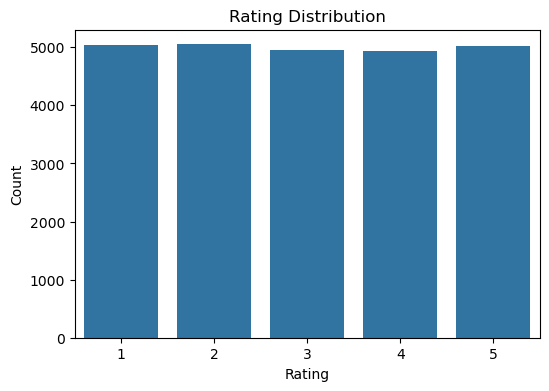

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="rating", data=df)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

## b) Purchase Conversion Rate

In [10]:
purchase_rate = df["purchase"].mean()

print("Purchase Conversion Rate:", purchase_rate)

Purchase Conversion Rate: 0.5004


- **This tell us that out of all the users that visited the website, ***50% of the users make a purchase.*****

## c) Sales across Categories

In [11]:
category_sales = df.groupby("category")["purchase"].sum()

category_sales = category_sales.sort_values(ascending=False)

category_sales

category
sportswear    1830
shoes         1822
bags          1802
tshirts       1790
jeans         1766
watches       1762
jackets       1738
Name: purchase, dtype: int64

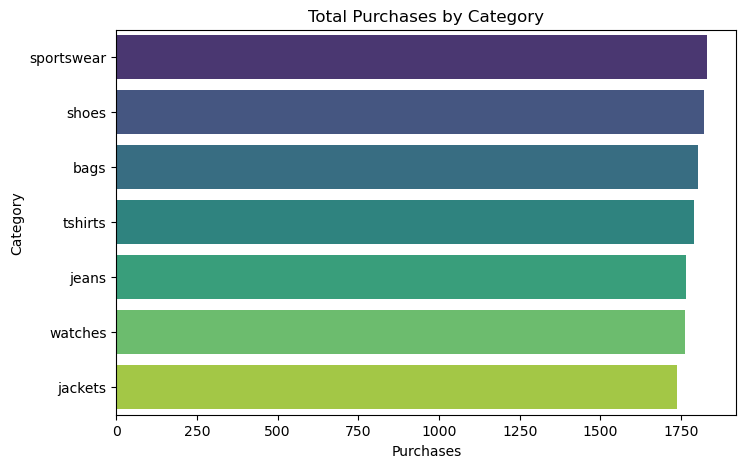

In [12]:
category_sales = df.groupby("category")["purchase"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index,
    palette="viridis"
)

plt.title("Total Purchases by Category")
plt.xlabel("Purchases")
plt.ylabel("Category")

plt.show()

- **Signals - ***Sportswear, Shoes, Bags, T-shirts, Jeans*** are the top 5 categories of demand among the audience.**
- **Hence could be recommended for promotions.**

## d) Sales across brands

In [13]:
brand_sales = df.groupby("brand")["purchase"].sum()

brand_sales = brand_sales.sort_values(ascending=False)

brand_sales

brand
Puma        1858
Roadster    1850
Adidas      1791
H&M         1779
Levis       1771
Zara        1759
Nike        1702
Name: purchase, dtype: int64

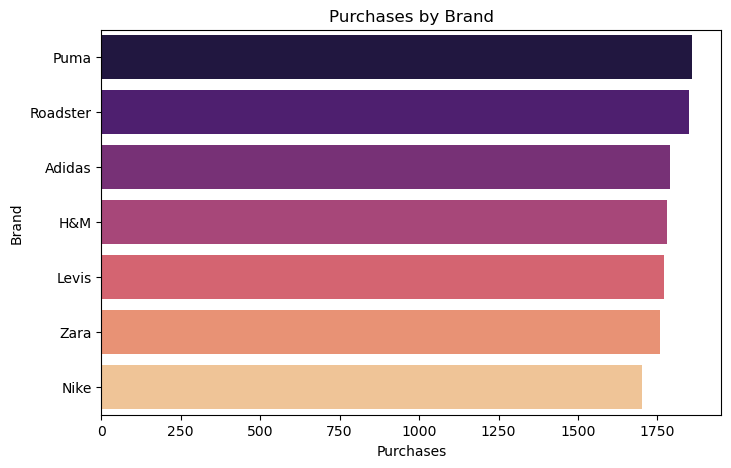

In [14]:
brand_sales = df.groupby("brand")["purchase"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=brand_sales.values,
    y=brand_sales.index,
    palette="magma"
)

plt.title("Purchases by Brand")
plt.xlabel("Purchases")
plt.ylabel("Brand")

plt.show()

- **Brands like ***Puma, Roadster, Adidas, H&M, Levis*** seem to have a strong-presence. These brands could aslo be evaluated on their brand loyalty to gain more insights.**

## e) Average Rating by Category

In [15]:
avg_rating_category = df.groupby("category")["rating"].mean()

avg_rating_category

category
bags          2.994985
jackets       2.984642
jeans         2.980764
shoes         3.007529
sportswear    2.999725
tshirts       2.965308
watches       3.021696
Name: rating, dtype: float64

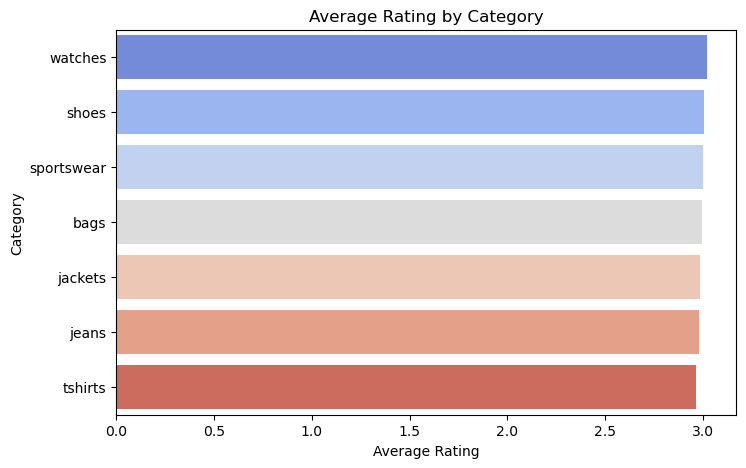

In [16]:
avg_rating_category = df.groupby("category")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index,
    palette="coolwarm"
)

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.show()

- **Highly rated categories indicate strong satisfaction.**

## f) Average Price by Category

In [17]:
avg_price_category = df.groupby("category")["price"].mean()

avg_price_category

category
bags          2757.056523
jackets       2738.689539
jeans         2792.370017
shoes         2754.047379
sportswear    2722.342715
tshirts       2724.905914
watches       2761.241807
Name: price, dtype: float64

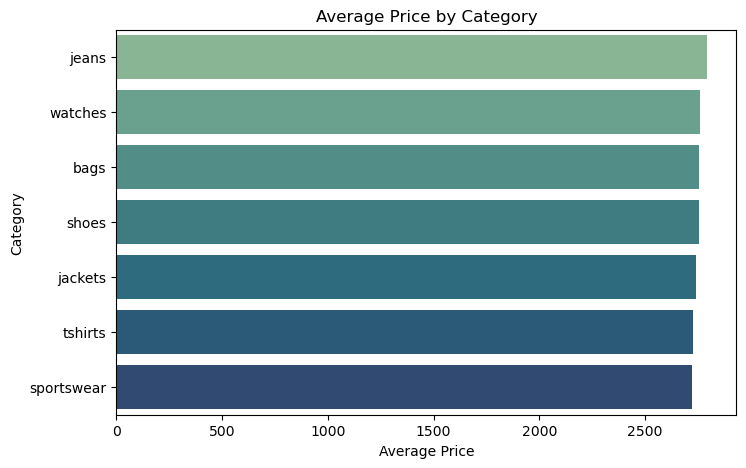

In [18]:
avg_price_category = df.groupby("category")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_price_category.values,
    y=avg_price_category.index,
    palette="crest"
)

plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")

plt.show()

- **Helps understand ***price sensitivity*****

## g) Discount vs Purchase Behavior

In [19]:
discount_purchase = df.groupby("discount")["purchase"].mean()

discount_purchase

discount
0     0.492406
10    0.499311
20    0.499507
30    0.501906
40    0.509162
Name: purchase, dtype: float64

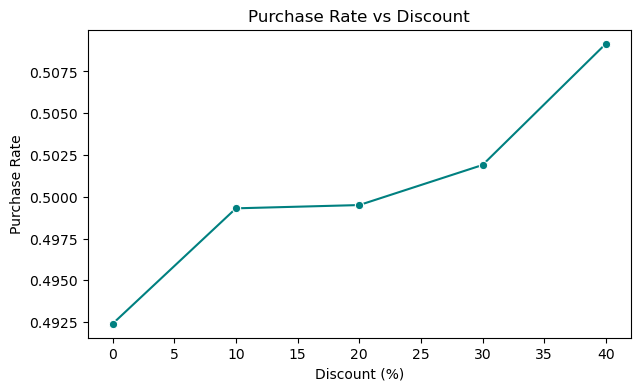

In [20]:
discount_purchase = df.groupby("discount")["purchase"].mean().reset_index()

plt.figure(figsize=(7,4))

sns.lineplot(
    x="discount",
    y="purchase",
    data=discount_purchase,
    marker="o",
    color="teal"
)

plt.title("Purchase Rate vs Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Purchase Rate")

plt.show()

- *****Higher discounts*** indicate ***higher purchase probability***.**

## h) Device Usage Analysis

In [21]:
device_usage = df["device"].value_counts()

device_usage

device
mobile     8412
tablet     8349
desktop    8239
Name: count, dtype: int64

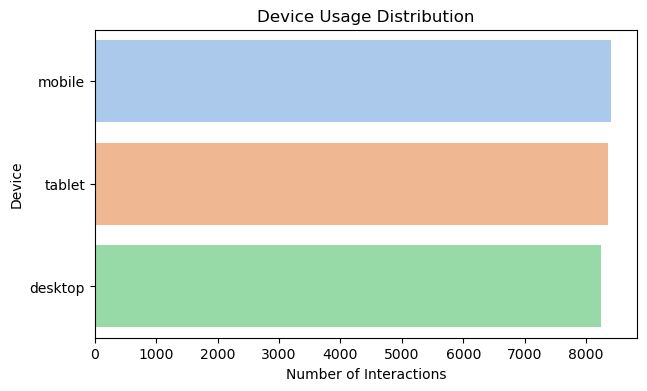

In [22]:
device_usage = df["device"].value_counts().reset_index()
device_usage.columns = ["device","count"]

plt.figure(figsize=(7,4))

sns.barplot(
    x="count",
    y="device",
    data=device_usage,
    palette="pastel"
)

plt.title("Device Usage Distribution")
plt.xlabel("Number of Interactions")
plt.ylabel("Device")

plt.show()

- **Comparatively users shop through ***mobiles*** rather than other means.**

## i) Purchase-Rate by Device

In [23]:
device_purchase = df.groupby("device")["purchase"].mean()

device_purchase

device
desktop    0.503702
mobile     0.499643
tablet     0.497904
Name: purchase, dtype: float64

- **Interestingly users prefer ***desktops*** for purchasing items than ***mobiles***.**

## j) Customer-Age Demographics

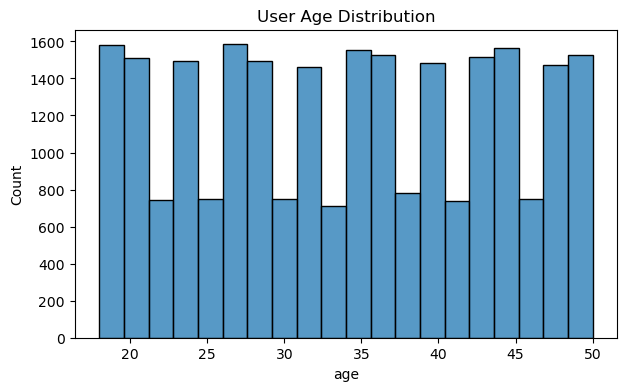

In [24]:
plt.figure(figsize=(7,4))

sns.histplot(df["age"], bins=20)

plt.title("User Age Distribution")

plt.show()

- **Helps us find the dominant user-segment**

## k) Gender-purchase Behavior

In [25]:
gender_purchase = df.groupby("gender")["purchase"].mean()

gender_purchase

gender
female    0.504460
male      0.496448
Name: purchase, dtype: float64

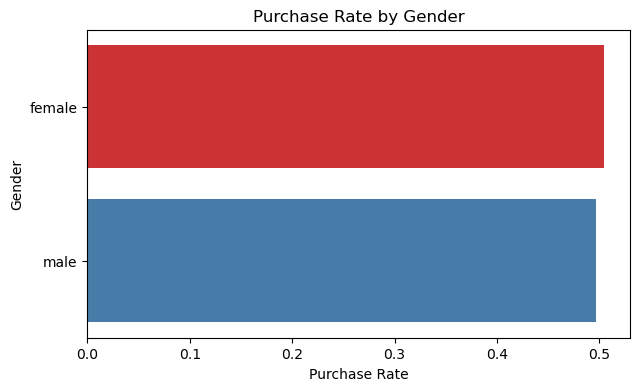

In [26]:
gender_purchase = df.groupby("gender")["purchase"].mean().reset_index()

plt.figure(figsize=(7,4))

sns.barplot(
    x="purchase",
    y="gender",
    data=gender_purchase,
    palette="Set1"
)

plt.title("Purchase Rate by Gender")
plt.xlabel("Purchase Rate")
plt.ylabel("Gender")

plt.show()

- **Indicates that Women seem to purchase more than Men.**

## l) City-wise Purchase Demographics

In [27]:
city_sales = df.groupby("city")["purchase"].sum()

city_sales = city_sales.sort_values(ascending=False)

city_sales

city
Kolkata      2121
Hyderabad    2103
Chennai      2086
Delhi        2080
Mumbai       2074
Bangalore    2046
Name: purchase, dtype: int64

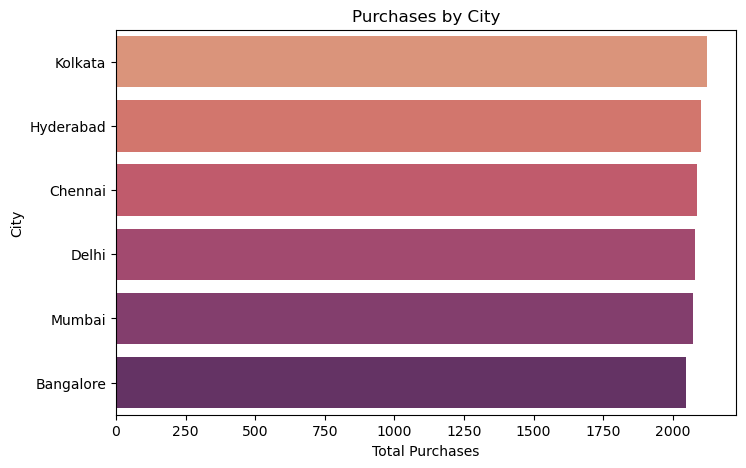

In [28]:
city_sales = df.groupby("city")["purchase"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x="purchase",
    y="city",
    data=city_sales,
    palette="flare"
)

plt.title("Purchases by City")
plt.xlabel("Total Purchases")
plt.ylabel("City")

plt.show()

- **Shows us the cities through which most customers finalize a purchase.**

## m) Session Duration vs Purchase

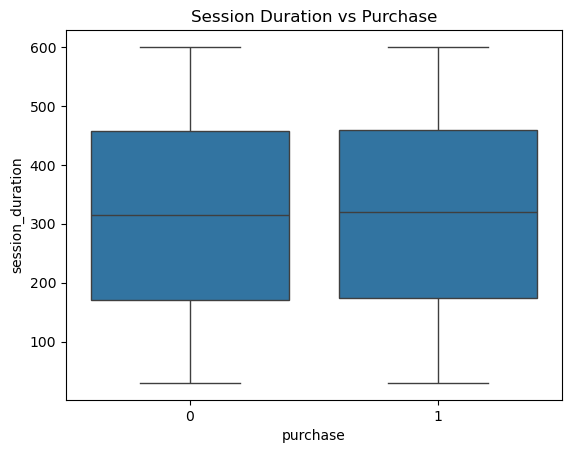

In [29]:
sns.boxplot(x="purchase", y="session_duration", data=df)

plt.title("Session Duration vs Purchase")

plt.show()

- **Shows us which users typically spend longer time browsing before making a purchase.**

## n) Category Preference by Gender

In [30]:
gender_category = pd.crosstab(
    df["category"],
    df["gender"]
)

gender_category

gender,female,male
category,,
bags,1768,1821
jackets,1720,1796
jeans,1722,1813
shoes,1772,1814
sportswear,1817,1822
tshirts,1838,1794
watches,1695,1808


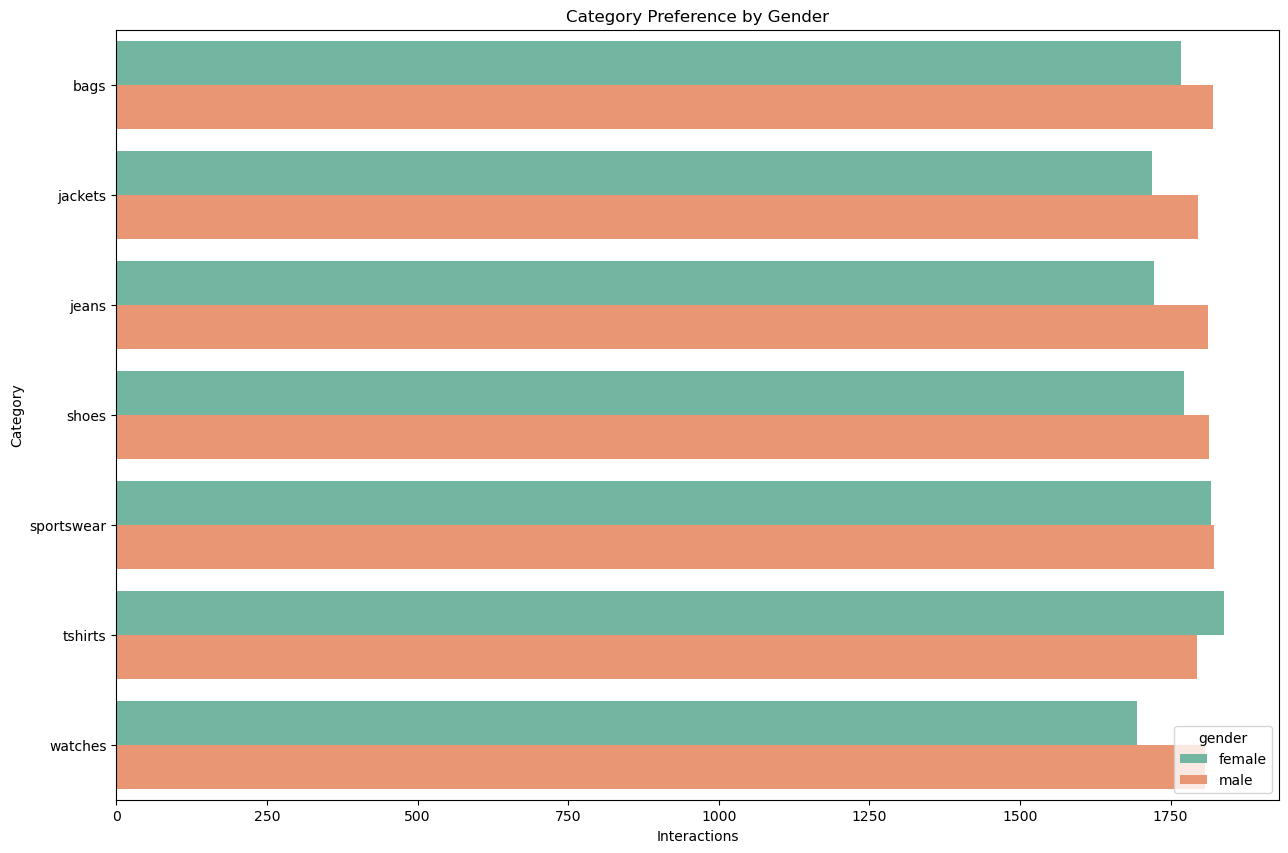

In [31]:
gender_category = pd.crosstab(df["category"], df["gender"]).reset_index()

gender_category = gender_category.melt(
    id_vars="category",
    var_name="gender",
    value_name="count"
)

plt.figure(figsize=(15,10))

sns.barplot(
    x="count",
    y="category",
    hue="gender",
    data=gender_category,
    palette="Set2"
)

plt.title("Category Preference by Gender")
plt.xlabel("Interactions")
plt.ylabel("Category")

plt.show()

In [32]:
df

,user_id,age,gender,city,device,membership_level,product_id,category,brand,price,discount,rating,purchase,add_to_cart,session_duration,timestamp
0,user_654,45,male,Delhi,mobile,regular,product_57,shoes,H&M,1737.63,10,2,0,0,268,2026-03-04 01:58:20
1,user_517,35,male,Mumbai,tablet,silver,product_13,bags,Adidas,3722.09,40,4,0,1,378,2026-01-11 19:25:12
2,user_284,40,female,Delhi,tablet,silver,product_79,tshirts,Roadster,2014.68,0,4,0,1,579,2026-01-03 10:16:45
3,user_127,20,male,Bangalore,mobile,regular,product_193,shoes,Zara,1819.30,40,3,0,0,133,2026-01-27 16:51:53
4,user_389,35,male,Chennai,tablet,regular,product_142,watches,H&M,4253.50,10,3,1,0,576,2026-01-24 18:38:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,user_623,39,male,Kolkata,tablet,regular,product_118,shoes,Nike,2873.41,0,4,0,1,231,2026-01-12 20:20:17
24996,user_324,33,female,Kolkata,desktop,gold,product_15,jeans,Roadster,3095.80,0,3,0,1,517,2026-03-05 10:04:08
24997,user_785,35,male,Hyderabad,tablet,silver,product_218,sportswear,H&M,2800.97,30,2,0,0,450,2026-02-24 12:49:12
24998,user_163,20,female,Chennai,mobile,silver,product_76,sportswear,Adidas,1988.18,10,5,0,1,390,2026-02-01 10:52:43


## 5) Building Recommendation Systems

In [33]:
# Converting timestamp object into datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [34]:
# Creating Interaction Score

df["interaction_score"] = (df["purchase"]*3 + df["add_to_cart"]*2 + df["rating"])

In [35]:
# Train-Test Split for future recommendations by splitting user interactions

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

## a) Popularity Based Recommender

In [36]:
# Training

product_popularity = train_df.groupby("product_id")["interaction_score"].sum()
product_popularity = product_popularity.sort_values(ascending=False)

In [37]:
# Recommendation function

def recommend_popular(n=5):
    
    return product_popularity.head(n).index.tolist()

In [38]:
recommend_popular(5)

['product_219', 'product_27', 'product_149', 'product_50', 'product_230']

## b) Item-Based Collaborative Filtering

In [39]:
# Building User-Item Matrix

user_item_matrix = train_df.pivot_table(index="user_id", columns="product_id", values="interaction_score")
user_item_matrix = user_item_matrix.fillna(0)

In [40]:
# Computing Item Similarity

from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

In [41]:
# Recommendation function

def recommend_similar_products(product_id, top_n=5):
    
    similar_scores = item_similarity_df[product_id]
    
    similar_scores = similar_scores.sort_values(ascending=False)
    
    return similar_scores.iloc[1:top_n+1].index.tolist()

## c) Content-Based Recommender

In [42]:
# Product Feature Table

product_features = train_df[["product_id","category","brand","price"]].drop_duplicates()

In [43]:
product_features = product_features.drop_duplicates("product_id")

In [44]:
# One-hot encoding

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

encoded_features = encoder.fit_transform(product_features[["category","brand"]]).toarray()

In [45]:
# Combine Price Feature

price_feature = product_features[["price"]].values

product_matrix = np.hstack([encoded_features, price_feature])

In [46]:
# Computing Similarity

content_similarity = cosine_similarity(product_matrix)

content_similarity_df = pd.DataFrame(content_similarity, index=product_features["product_id"], columns=product_features["product_id"])

In [47]:
# Recommendation function

def content_recommend(product_id, top_n=5):
    
    similar_scores = content_similarity_df.loc[product_id]

    similar_scores = similar_scores.sort_values(ascending=False)

    return similar_scores.iloc[1:top_n+1].index.tolist()

## 6) Evaluating Recommender Models

### a) Precision@K

In [48]:
# Precision@K Function

def precision_at_k(recommended, relevant, k):
    
    recommended = recommended[:k]
    relevant_set = set(relevant)
    hits = len(set(recommended) & relevant_set)
    return hits / k

### b) Recall@K

In [49]:
# Recall@K Function

def recall_at_k(recommended, relevant, k):
    
    recommended = recommended[:k]
    relevant_set = set(relevant)
    hits = len(set(recommended) & relevant_set)
    return hits / len(relevant_set) if relevant_set else 0

### c) Evaluating Popularity Model

In [50]:
k = 5

pop_precision = []
pop_recall = []

popular_recs = recommend_popular(k)

for user in test_df["user_id"].unique():
    
    relevant = test_df[test_df["user_id"] == user]["product_id"].tolist()
    
    precision = precision_at_k(popular_recs, relevant, k)
    recall = recall_at_k(popular_recs, relevant, k)
    
    pop_precision.append(precision)
    pop_recall.append(recall)

print("Popularity Precision@5:", np.mean(pop_precision))
print("Popularity Recall@5:", np.mean(pop_recall))

Popularity Precision@5: 0.015415415415415417
Popularity Recall@5: 0.015358251469362582


### d) Evaluating Collaborative Filtering Model

In [51]:
collab_precision = []
collab_recall = []

for user in test_df["user_id"].unique():
    
    user_products = train_df[train_df["user_id"]==user]["product_id"].tolist()
    
    if len(user_products)==0:
        continue
    
    product = user_products[0]
    
    recs = recommend_similar_products(product,5)
    
    relevant = test_df[test_df["user_id"]==user]["product_id"].tolist()
    
    precision = precision_at_k(recs, relevant, 5)
    recall = recall_at_k(recs, relevant, 5)
    
    collab_precision.append(precision)
    collab_recall.append(recall)

print("Collaborative Precision@5:", np.mean(collab_precision))
print("Collaborative Recall@5:", np.mean(collab_recall))

Collaborative Precision@5: 0.015815815815815818
Collaborative Recall@5: 0.016071663293885517


### e) Evaluating Content-Based Model

In [52]:
content_precision = []
content_recall = []

for user in test_df["user_id"].unique():
    
    user_products = train_df[train_df["user_id"]==user]["product_id"].tolist()
    
    if len(user_products)==0:
        continue
    
    product = user_products[0]
    
    recs = content_recommend(product,5)
    
    relevant = test_df[test_df["user_id"]==user]["product_id"].tolist()
    
    precision = precision_at_k(recs, relevant, 5)
    recall = recall_at_k(recs, relevant, 5)
    
    content_precision.append(precision)
    content_recall.append(recall)

print("Content Precision@5:", np.mean(content_precision))
print("Content Recall@5:", np.mean(content_recall))

Content Precision@5: 0.018418418418418417
Content Recall@5: 0.01985278929723374


## 7) Conclusion

- **Content-Based Recommender performed the best(Precision=0.018, Recall=0.019) and Popularity Recommender the worst(Precision = 0.0.15, Recall = 0.015).**
- **This is completely normal for synthetic datasets created with random behavior.**
- **This dataset was generated using Faker, so user preferences are mostly random. There is no strong pattern for the model to learn.**
- **On real Streaming or E-commerce platforms like Netflix, Spotify, Flipkart or Myntra; there are millions of users, strong behavioral signals, repeated purchases, clear product clusters. Hence their metrics are higher.**
- **Recommendation problems are very sparse which makes the problem very hard to be hard solved unless you have enough and clear data to evaluate on.**